#Pipeline
Raw ADR dataset  ->  Clean and filter data  ->  Convert text labels to IDs  ->  Create graph nodes and edges  ->  Split triples into train / val / test  ->  Generate negative samples  ->  RGCN learns node embeddings  ->  MLP scorer evaluates each triple  ->  Sigmoid converts score to probability  ->  Choose best threshold on validation set  ->  Evaluate on test set  ->   Save model and use later for prediction

In [ ]:
!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.4 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)

from torch_geometric.nn import RGCNConv
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:

# -----------------------------
# 2. Reproducibility
# -----------------------------
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)


MAX_ROWS: use only up to 500k rows to keep training manageable

USE_ONLY_PT: keep only PT-level side effects

MIN_SE_FREQ: remove very rare side effects

NEG_PER_POS: create 3 fake negative examples for every real positive one

In [ ]:
# ============================================
# 3. Config
# ============================================
DATA_PATH = "/content/drive/MyDrive/merged_data.csv"
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/rgcn_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Data controls
MAX_ROWS = 500_000       #2,491,362
USE_ONLY_PT = True
MIN_SE_FREQ = 20
NEG_PER_POS = 3

# Model
EMBED_DIM = 64          #starting embedding size
HIDDEN_DIM = 128        #hidden representation size after graph convolution
NUM_LAYERS = 2          #how many RGCN layers to use
DROPOUT = 0.3           #regularization to reduce overfitting/memorization. model randomly ignore 30% of hidden value.
MLP_HIDDEN = 256        #size of the hidden layer in the scorer

# Training
LR = 5e-4               #learning rate controls how big each model update is during training. too big -> model not learn well. too small -> long training
WEIGHT_DECAY = 1e-5     #keep the model simpler and reduces overfitting
EPOCHS = 50
PATIENCE = 5            #early stopping. if validation PR-AUC not improve for 5 epoh, stop training
TRAIN_BATCH_SIZE = 4096 #for batch training. model train 4096 examples each batch
EVAL_BATCH_SIZE = 8192  #validate/test batch


Using device: cuda


In [ ]:
# =========================================================
# 4. Load raw data
# =========================================================

df_original = pd.read_csv(DATA_PATH)

print("Original shape:", df_original.shape)

# Show first few rows
print("\nFirst 5 rows:")
print(df_original.head())

Original shape: (9312040, 8)

First 5 rows:
  stitch_id_flat umls_id_se concept_type  side_effect_name meddra_type  \
0   CID100000085   C0000729          LLT  Abdominal cramps         LLT   
1   CID100000085   C0000729          LLT  Abdominal cramps          PT   
2   CID100000085   C0000729          LLT  Abdominal cramps         LLT   
3   CID100000085   C0000729          LLT  Abdominal cramps          PT   
4   CID100000085   C0000729          LLT  Abdominal cramps         LLT   

   umls_id2        indication_name  drug_name  
0  C0015544      Failure to thrive  carnitine  
1  C0015544      Failure to thrive  carnitine  
2  C0020615          Hypoglycaemia  carnitine  
3  C0020615          Hypoglycaemia  carnitine  
4  C0022661  Renal failure chronic  carnitine  


In [ ]:
# ============================================
# 5. Clean data
# ============================================
df = df_original.copy()

#checks required columns exist
required_cols = [
    "drug_name",
    "side_effect_name",
    "indication_name",
    "meddra_type",
]

#fills missing text with empty strings
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

#lowercases text
for col in required_cols:
    df[col] = df[col].fillna("").astype(str).str.strip().str.lower()

#keeps only PT records if requested
if USE_ONLY_PT:
    df = df[df["meddra_type"] == "pt"].copy()

#removes blank rows
df = df[
    (df["drug_name"] != "")
    & (df["side_effect_name"] != "")
    & (df["indication_name"] != "")
].copy()

print(f"Rows after basic cleaning: {len(df):,}")

#removes duplicates
df = df.drop_duplicates(
    subset=["drug_name", "indication_name", "side_effect_name"]
).reset_index(drop=True)

print(f"Rows after deduplication: {len(df):,}")

#removes rare side effects. count the side effects. if side effects appears >= min_se_freq (20), keep
se_counts = df["side_effect_name"].value_counts()
keep_se = se_counts[se_counts >= MIN_SE_FREQ].index
df = df[df["side_effect_name"].isin(keep_se)].copy().reset_index(drop=True)

print(f"Rows after dropping rare side effects: {len(df):,}")
print(f"Remaining unique side effects: {df['side_effect_name'].nunique():,}")

#samples down to 500k rows if needed
if len(df) > MAX_ROWS:
    df = df.sample(n=MAX_ROWS, random_state=42).reset_index(drop=True)

#saves the cleaned sample
print(f"Rows used for training: {len(df):,}")

df.to_csv(os.path.join(SAVE_DIR, "rgcn_sample_used.csv"), index=False)


Rows after basic cleaning: 4,710,469
Rows after deduplication: 2,505,988
Rows after dropping rare side effects: 2,491,362
Remaining unique side effects: 4,394
Rows used for training: 500,000


This block builds the vocabulary for the graph. It collects all unique drugs, indications, and side effects, converts them into numeric IDs, and then uses offsets so all three node types can exist in one shared graph without ID overlap.

e.g
aspirin  → drug_id = 0,
pain     → ind_id  = 12,
nausea   → se_id   = 47.
So a row becomes:
(0, 12, 47)


In [ ]:
# =========================================================
# 6. Build vocabularies
# =========================================================

#finds all the unique values
drug_names = sorted(df["drug_name"].unique())
indication_names = sorted(df["indication_name"].unique())
side_effect_names = sorted(df["side_effect_name"].unique())

#creates a mapping from each text value to a numeric ID
drug2id = {name: i for i, name in enumerate(drug_names)}
ind2id = {name: i for i, name in enumerate(indication_names)}
se2id = {name: i for i, name in enumerate(side_effect_names)}

#creates the reverse mapping. After prediction, the model output IDs. and we need a way to convert those numbers back into readable names.
id2drug = {i: name for name, i in drug2id.items()}
id2ind = {i: name for name, i in ind2id.items()}
id2se = {i: name for name, i in se2id.items()}

#Count how many unique drugs, indications, and side effects
num_drugs = len(drug2id)
num_inds = len(ind2id)
num_ses = len(se2id)

#Assign offset positions for each node type. To avoid overlapped IDs. E.g. drug IDs use positions 0,1,2. indication IDs use positions 3,4. side effect IDs use positions 5,6,7,8
drug_offset = 0
ind_offset = num_drugs
se_offset = num_drugs + num_inds
num_nodes = num_drugs + num_inds + num_ses

#converts a drug’s local ID into its position in the full graph.
def drug_global_id_from_local(drug_id):
    return drug_offset + drug_id

#Convert local indication ID to global graph ID
def ind_global_id_from_local(ind_id):
    return ind_offset + ind_id

#Convert local side effect ID to global graph ID
def se_global_id_from_local(se_id):
    return se_offset + se_id

print("num_drugs :", num_drugs)
print("num_inds  :", num_inds)
print("num_ses   :", num_ses)
print("num_nodes :", num_nodes)


num_drugs : 1276
num_inds  : 2201
num_ses   : 4392
num_nodes : 7869


This block converts each drug–indication–side effect record (aspirin + pain + nausea) into numeric IDs (0, 12, 47), stores them as triples, and splits the known true triples into training, validation, and test sets.

train/valid/test split - 72 / 13 / 15

These are called positive triples because they are known true relationships from your data.

Later in another block(called negative sampling), create negative triples by corrupting one part of the triple, so the model can learn the difference between true and false combinations.

In [ ]:
# =========================================================
# 7. Convert triples to integer IDs
# =========================================================

#Keep only the 3 columns needed for triples. For the graph model, each record is treated as a triple (drug, indication, side_effect)
triples_df = df[["drug_name", "indication_name", "side_effect_name"]].copy()

#Convert drug, indication, and side effect names into numeric IDs
triples_df["drug_id"] = triples_df["drug_name"].map(drug2id)
triples_df["ind_id"] = triples_df["indication_name"].map(ind2id)
triples_df["se_id"] = triples_df["side_effect_name"].map(se2id)

#Turn the ID columns into a list of tuples.The model later works with triples in tuple form, not as a full DataFrame
#index=False means do not include row index. name=None means return plain tuples, not named tuples
triples_id = list(
    triples_df[["drug_id", "ind_id", "se_id"]].itertuples(index=False, name=None)
)

#Store all true triples in a set
all_positive_set = set(triples_id)

#First split into training and test positives. 15% going to the test set
train_pos, test_pos = train_test_split(
    triples_id, test_size=0.15, random_state=42
)

#Split training again into train and validation. takes the temporary training portion from above and splits it again into train and val
train_pos, val_pos = train_test_split(
    train_pos, test_size=0.15, random_state=42
)

print(f"Train positives: {len(train_pos):,}")
print(f"Val positives:   {len(val_pos):,}")
print(f"Test positives:  {len(test_pos):,}")



Train positives: 361,250
Val positives:   63,750
Test positives:  75,000


This block builds the graph used by the RGCN. For each training triple, it creates edges between the drug and indication, and between the drug and side effect, along with reverse edges. These edges are stored with relation-type labels so the RGCN can distinguish different kinds of connections during message passing.

In [ ]:
# =========================================================
# 8. Build graph edges for message passing
# =========================================================

#Define relation type numbers
REL_HAS_IND = 0         #drug → indication
REL_CAUSES_SE = 1       #drug → side effect
REL_REV_HAS_IND = 2     #indication → drug
REL_REV_CAUSES_SE = 3   #side effect → drug
NUM_RELATIONS = 4

#Create empty lists to store graph edges
edge_src = []
edge_dst = []
edge_type_list = []

#Loop through each positive training triple. Convert local IDs into global graph IDs
for d_id, i_id, s_id in train_pos:
    d_global = drug_global_id_from_local(d_id)
    i_global = ind_global_id_from_local(i_id)
    s_global = se_global_id_from_local(s_id)

    # Add edge for drug → indication. tells the graph that this drug is connected to this indication
    edge_src.append(d_global)
    edge_dst.append(i_global)
    edge_type_list.append(REL_HAS_IND)

    #Add edge for drug → side effect. tells the graph that this drug is linked to this side effect.
    edge_src.append(d_global)
    edge_dst.append(s_global)
    edge_type_list.append(REL_CAUSES_SE)

    # Add reverse edge for indication → drug. the indication node can also send information back to the drug node.
    edge_src.append(i_global)
    edge_dst.append(d_global)
    edge_type_list.append(REL_REV_HAS_IND)

    #Add reverse edge for side effect → drug. information can move back from side effects to drugs.
    edge_src.append(s_global)
    edge_dst.append(d_global)
    edge_type_list.append(REL_REV_CAUSES_SE)

#Convert the edge lists into PyTorch tensors. it stores all those edges in tensor form so the RGCN can perform message passing.
edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
edge_type = torch.tensor(edge_type_list, dtype=torch.long)

print("edge_index shape:", edge_index.shape)
print("edge_type shape :", edge_type.shape)

edge_index shape: torch.Size([2, 1445000])
edge_type shape : torch.Size([1445000])


create negative triples by corrupting one part of the triple, so the model can learn the difference between true and false combinations.

real positive triple  ->  randomly change one part ->  check it is not actually a true triple  ->  keep it as a fake negative example

In [ ]:
# =========================================================
# 9. Negative sampling
# =========================================================

#generate fake negative triples from a set of positive triples.
def sample_negative_triples(pos_triples, neg_per_pos=3):
    negatives = []          #store all generated fake triples
    used = set()            #keeps track of which fake triples have already been created

    #Create lists of possible IDs
    drug_ids = np.arange(num_drugs)
    ind_ids = np.arange(num_inds)
    se_ids = np.arange(num_ses)

    #calculates the total number of negative samples to create.
    target_neg = int(len(pos_triples) * neg_per_pos)

    while len(negatives) < target_neg:
        d_id, i_id, s_id = random.choice(pos_triples)       #randomly picks one real positive triple. Negative sampling starts from a real triple, then changes one part to make it fake.

        #Randomly choose which part of the triple to corrupt. creates variety in the fake triples.
        corrupt_which = random.choices(
            ["drug", "ind", "se"],
            weights=[0.2, 0.2, 0.6],
            k=1
        )[0]

        if corrupt_which == "drug":                 #If corrupting the drug, triple get false drug
            d_new = int(np.random.choice(drug_ids))
            candidate = (d_new, i_id, s_id)
        elif corrupt_which == "ind":                #If corrupting the drug, triple get a false indication
            i_new = int(np.random.choice(ind_ids))
            candidate = (d_id, i_new, s_id)
        else:
            s_new = int(np.random.choice(se_ids))
            candidate = (d_id, i_id, s_new)

        if candidate in all_positive_set:           #checks whether the newly created candidate triple already exists in the real dataset. if yes, skip
            continue
        if candidate in used:                       #Reject the candidate if it was already generated before
            continue

        used.add(candidate)                         #save the valid candidate to used
        negatives.append(candidate)                 #Save the valid negative candidate

    return negatives

#Generate train, validation, and test negatives
train_neg = sample_negative_triples(train_pos, NEG_PER_POS)
val_neg = sample_negative_triples(val_pos, NEG_PER_POS)
test_neg = sample_negative_triples(test_pos, NEG_PER_POS)

print(f"Train negatives: {len(train_neg):,}")
print(f"Val negatives:   {len(val_neg):,}")
print(f"Test negatives:  {len(test_neg):,}")

Train negatives: 1,083,750
Val negatives:   191,250
Test negatives:  225,000


This block combines positive and negative triples into one dataset, assigns labels of 1 and 0, shuffles the rows, and creates the final train, validation, and test arrays used by the model.

In [ ]:
# =========================================================
# 10. Build datasets
# =========================================================
def build_examples(pos_triples, neg_triples):
    triples_out = pos_triples + neg_triples             #Combine positive and negative triples
    labels = np.array(                                  #Create labels for positives and negatives. The model needs to know the correct answer for true rls/false rls
        [1.0] * len(pos_triples) + [0.0] * len(neg_triples),
        dtype=np.float32
    )

    idx = np.arange(len(triples_out))           #create array index. index array is used to shuffle the dataset while keeping triples and labels aligned.
    np.random.shuffle(idx)                      #shuffle. Without shuffling, all positives would come first and all negatives would come after.

    #keeps the input examples and correct labels matched after shuffling.
    triples_out = np.array(triples_out, dtype=np.int64)[idx]
    labels = labels[idx]

    return triples_out, labels

train_examples, y_train = build_examples(train_pos, train_neg)      #Build the training dataset
val_examples, y_val = build_examples(val_pos, val_neg)              #Build the validation dataset
test_examples, y_test = build_examples(test_pos, test_neg)          #Build the test dataset

print("train_examples:", train_examples.shape)
print("val_examples  :", val_examples.shape)
print("test_examples :", test_examples.shape)


train_examples: (1445000, 3)
val_examples  : (255000, 3)
test_examples : (300000, 3)


it helps the model train on small chunks of data rather than the whole dataset at once, which is more memory-efficient and useful for large datasets. it remixes the order every training pass so batches are different each epoch

In [ ]:
# =========================================================
# 11. Minibatch iterator
# =========================================================
def iterate_minibatches(examples, labels, batch_size=4096, shuffle=True):
    n = len(examples)
    idx = np.arange(n)

    if shuffle:
        np.random.shuffle(idx)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_idx = idx[start:end]
        yield examples[batch_idx], labels[batch_idx]



This whole block builds a blueprint for graph-based ADR prediction model. these classes define the model architecture.

 The encoder class defines how node embeddings are learned from the graph. The RGCNEncoder learns better node embeddings by passing information through the graph.

 The scorer class defines how a drug–indication–side-effect triple is scored.

  The final RGCN model class combines the encoder and scorer into one full model so the notebook can encode the graph and score batches of triples during training and testing.
  
  The actual learning happens later during the training loop when the optimizer updates the weights.

In [ ]:
# =========================================================
# 12. Model
# =========================================================
class RGCNEncoder(nn.Module):
    def __init__(self, num_nodes, num_relations, emb_dim=64, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, emb_dim)            #Create starting embeddings for all nodes. At the beginning, these numbers are random.

        #builds a list of RGCN convolution layers
        self.convs = nn.ModuleList()                                #stores the RGCN convolution layers.
        if num_layers == 1:
            self.convs.append(RGCNConv(emb_dim, hidden_dim, num_relations))         #Converts 64-dimensional starting embeddings into 128-dimensional hidden embeddings
        else:
            self.convs.append(RGCNConv(emb_dim, hidden_dim, num_relations))
            for _ in range(num_layers - 2):
                self.convs.append(RGCNConv(hidden_dim, hidden_dim, num_relations))  ##Updates the 128-dimensional embeddings again using graph relationships
            self.convs.append(RGCNConv(hidden_dim, hidden_dim, num_relations))

        self.dropout = dropout

    #runs the node embeddings through the RGCN layers.
    def forward(self, edge_index, edge_type):
        x = self.node_emb.weight                    #gets the current embedding vector for every node
        for i, conv in enumerate(self.convs):           #Pass embeddings through each RGCN layer
            x = conv(x, edge_index, edge_type)
            if i < len(self.convs) - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return x

#creates the scoring network that will judge whether a triple is likely true
class MLPTripleScorer(nn.Module):
    def __init__(self, hidden_dim, mlp_hidden=256, dropout=0.3):
        super().__init__()
        input_dim = hidden_dim * 5  # d, i, s, d*s, i*s.d*s and i*s helps the model learn compatibility
        #defines a small feedforward neural network
        self.net = nn.Sequential(
            nn.Linear(input_dim, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, mlp_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden // 2, 1)
        )
    #combines the embeddings into one feature vector and sends it through the MLP
    def forward(self, z_drug, z_ind, z_se):
        x = torch.cat(
            [
                z_drug,
                z_ind,
                z_se,
                z_drug * z_se,
                z_ind * z_se,
            ],
            dim=-1
        )
        return self.net(x).squeeze(-1)

#Define the full combined model
class ADRRGCNModel(nn.Module):
    def __init__(self, num_nodes, num_relations, emb_dim=64, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.encoder = RGCNEncoder(
            num_nodes=num_nodes,
            num_relations=num_relations,
            emb_dim=emb_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
        )
        self.scorer = MLPTripleScorer(
            hidden_dim=hidden_dim,
            mlp_hidden=MLP_HIDDEN,
            dropout=dropout,
        )
    #a helper function that runs the graph through the encoder and returns all node embeddings
    def encode(self, edge_index, edge_type):
        return self.encoder(edge_index, edge_type)

    #takes a batch of triples and splits each triple
    def score_batch(self, z, triples_batch):
        triples_batch = torch.as_tensor(                        #the batch is in PyTorch tensor form, so the model can process it on CPU or GPU.
            triples_batch, dtype=torch.long, device=z.device
        )

        d_local = triples_batch[:, 0]               #Split each triple into drug, indication, side effect
        i_local = triples_batch[:, 1]
        s_local = triples_batch[:, 2]

        d_global = d_local + drug_offset            #Convert local IDs to global graph IDs. in one shared graph, everynode need unique ID.
        i_global = i_local + ind_offset
        s_global = s_local + se_offset

        z_drug = z[d_global]                        #pick only the embeddings needed for the current triple.
        z_ind = z[i_global]
        z_se = z[s_global]

        return self.scorer(z_drug, z_ind, z_se)         #return one score for required triple

This block evaluates the trained RGCN model by scoring examples in batches, converting raw scores into probabilities, selecting a good threshold, and calculating performance metrics such as ROC-AUC, PR-AUC, F1, precision, and recall.

In [ ]:
# =========================================================
# 13. Evaluation helpers
# =========================================================

#defines a function that gets prediction probabilities for many examples
@torch.no_grad()
def get_probs(model, edge_index, edge_type, examples, batch_size=8192):
    model.eval()
    z = model.encode(edge_index, edge_type)                 #runs the graph through the RGCN encoder and creates learned embeddings for all nodes.

    all_probs = []

    dummy_labels = np.zeros(len(examples), dtype=np.float32)

    #Predict probabilities batch by batch
    for batch_examples, _ in iterate_minibatches(                       #splits all examples into smaller batches
        examples, dummy_labels, batch_size=batch_size, shuffle=False
    ):
        logits = model.score_batch(z, batch_examples)               #splits all examples into smaller batches
        probs = torch.sigmoid(logits)                               #turn raw scores from scorer into probabilities
        all_probs.append(probs.detach().cpu().numpy())                  #save prob as numpy arrays

    return np.concatenate(all_probs)                    #combine all batches

#tries different probability cutoffs to see which one gives the best F1 score
def find_best_threshold(y_true, probs):
    thresholds = np.arange(0.10, 0.91, 0.05)
    best_thr = 0.5                          #Default starting values
    best_f1 = -1

    for thr in thresholds:                              #Test each threshold. keep the threshold that gives the highest F1
        preds = (probs >= thr).astype(int)                 #convert probability into prediction. keep probability better than threshold as 1
        f1 = f1_score(y_true, preds, zero_division=0)       #calculate f1
        if f1 > best_f1:                                #If this threshold gives a better F1 than previous thresholds, save i
            best_f1 = f1
            best_thr = thr

    return best_thr, best_f1

#main evaluation function
@torch.no_grad()
def evaluate(model, edge_index, edge_type, examples, labels, batch_size=8192, threshold=0.5):
    model.eval()
    z = model.encode(edge_index, edge_type)

    all_logits = []
    all_probs = []

    for batch_examples, batch_labels in iterate_minibatches(
        examples, labels, batch_size=batch_size, shuffle=False
    ):
        logits = model.score_batch(z, batch_examples)
        probs = torch.sigmoid(logits)

        all_logits.append(logits.detach().cpu().numpy())
        all_probs.append(probs.detach().cpu().numpy())

    logits = np.concatenate(all_logits)
    probs = np.concatenate(all_probs)
    preds = (probs >= threshold).astype(int)
    labels = labels.astype(int)

    metrics = {
        "roc_auc": roc_auc_score(labels, probs),
        "pr_auc": average_precision_score(labels, probs),
        "f1": f1_score(labels, preds, zero_division=0),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
    }
    return metrics, probs

This block initializes the RGCN model, moves it and graph data to the correct device, sets up Adam to update the model weights, and creates a weighted binary loss function so positive triples matter enough despite having more negative samples.

.for every real positive triple, we created 3 fake negative triples. Pos_weight = 3 tells the loss function Positive mistakes should matter 3 times more. Without it, negatives samples will dominate the model.

In [ ]:
# =========================================================
# 14. Initialize model / optimizer / loss
# =========================================================

#Create the full model
model = ADRRGCNModel(
    num_nodes=num_nodes,
    num_relations=NUM_RELATIONS,
    emb_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

#moves the graph structure data to the same device as the model
edge_index = edge_index.to(DEVICE)
edge_type = edge_type.to(DEVICE)

#creates the optimizer that will update the model weights during training. Adam adjusts the model weights so the predictions become better over time
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

#Count positive and negative training examples
num_pos = len(train_pos)
num_neg = len(train_neg)
pos_weight_value = num_neg / max(num_pos, 1)        #weight helps balance the loss so positive examples matter more
print("pos_weight:", pos_weight_value)

#creates the loss function used for binary classification.
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
)


pos_weight: 3.0


This block trains the model epoch by epoch, evaluates it on validation data, tunes the threshold, saves the best model, and uses early stopping to avoid unnecessary training.

In [ ]:
# =========================================================
# 15. Train
# =========================================================

#creates variables to track the best validation performance during training
best_val_pr = -np.inf
best_state = None
best_threshold = 0.5
patience_counter = 0
history = []


for epoch in range(1, EPOCHS + 1):              #starts the training loop over all epochs
    model.train()

    total_loss = 0.0
    total_examples = 0

    for batch_examples, batch_labels in iterate_minibatches(                    #splits the training data into smaller mini-batches and loops through them
        train_examples, y_train, batch_size=TRAIN_BATCH_SIZE, shuffle=True
    ):
        optimizer.zero_grad()

        z = model.encode(edge_index, edge_type)             #runs the graph through the encoder and gets the current node embeddings

        batch_labels_t = torch.tensor(
            batch_labels, dtype=torch.float32, device=DEVICE
        )
        logits = model.score_batch(z, batch_examples)           #raw prediction scores for the current batch

        loss = criterion(logits, batch_labels_t)                #Compute loss and update weights
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(batch_examples)         #adds the batch loss into a running total.
        total_examples += len(batch_examples)

    train_loss = total_loss / max(total_examples, 1)

    # validation with threshold tuning
    val_metrics_raw, val_probs = evaluate(
        model,
        edge_index,
        edge_type,
        val_examples,
        y_val,
        batch_size=EVAL_BATCH_SIZE,
        threshold=0.5
    )

    epoch_best_thr, epoch_best_f1 = find_best_threshold(        #Find best validation threshold
        y_val.astype(int), val_probs
    )

    val_metrics, _ = evaluate(                      #Re-evaluate validation using best threshold
        model,
        edge_index,
        edge_type,
        val_examples,
        y_val,
        batch_size=EVAL_BATCH_SIZE,
        threshold=epoch_best_thr
    )

    row = {                                         #stores the results from the current epoch in a dictionary and appends it to history
        "epoch": epoch,
        "train_loss": train_loss,
        "best_threshold": epoch_best_thr,
        **val_metrics
    }
    history.append(row)

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val ROC-AUC: {val_metrics['roc_auc']:.4f} | "
        f"Val PR-AUC: {val_metrics['pr_auc']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val Precision: {val_metrics['precision']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f} | "
        f"Thr: {epoch_best_thr:.2f}"
    )

    if val_metrics["pr_auc"] > best_val_pr:                 #Check if this is the best model so far
        best_val_pr = val_metrics["pr_auc"]
        best_threshold = epoch_best_thr
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        patience_counter = 0
    else:                                                   #Early stopping if no improvement
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

Epoch 001 | Train Loss: 0.7753 | Val ROC-AUC: 0.9037 | Val PR-AUC: 0.7176 | Val F1: 0.7115 | Val Precision: 0.6364 | Val Recall: 0.8067 | Thr: 0.80
Epoch 002 | Train Loss: 0.5424 | Val ROC-AUC: 0.9338 | Val PR-AUC: 0.7834 | Val F1: 0.7646 | Val Precision: 0.7028 | Val Recall: 0.8384 | Thr: 0.80
Epoch 003 | Train Loss: 0.4668 | Val ROC-AUC: 0.9439 | Val PR-AUC: 0.8065 | Val F1: 0.7859 | Val Precision: 0.7291 | Val Recall: 0.8523 | Thr: 0.80
Epoch 004 | Train Loss: 0.4271 | Val ROC-AUC: 0.9488 | Val PR-AUC: 0.8190 | Val F1: 0.7990 | Val Precision: 0.7199 | Val Recall: 0.8975 | Thr: 0.75
Epoch 005 | Train Loss: 0.4000 | Val ROC-AUC: 0.9530 | Val PR-AUC: 0.8285 | Val F1: 0.8106 | Val Precision: 0.7551 | Val Recall: 0.8749 | Thr: 0.80
Epoch 006 | Train Loss: 0.3793 | Val ROC-AUC: 0.9555 | Val PR-AUC: 0.8358 | Val F1: 0.8186 | Val Precision: 0.7554 | Val Recall: 0.8934 | Thr: 0.80
Epoch 007 | Train Loss: 0.3643 | Val ROC-AUC: 0.9580 | Val PR-AUC: 0.8426 | Val F1: 0.8257 | Val Precision: 0.76

In [ ]:
# =========================================================
# 16. Restore best model
# =========================================================
if best_state is not None:
    model.load_state_dict(best_state)

print("Best validation PR-AUC:", best_val_pr)
print("Best validation threshold:", best_threshold)


Best validation PR-AUC: 0.8861821902529871
Best validation threshold: 0.7500000000000002


In [ ]:
# =========================================================
# 17. Save training outputs
# =========================================================
torch.save(model.state_dict(), os.path.join(SAVE_DIR, "rgcn_model_v2_22apr.pth"))
pd.DataFrame(history).to_csv(
    os.path.join(SAVE_DIR, "training_history_v2_22apr.csv"),
    index=False
)

In [ ]:
# =========================================================
# 18. Final test
# =========================================================
test_metrics, test_probs = evaluate(
    model,
    edge_index,
    edge_type,
    test_examples,
    y_test,
    batch_size=EVAL_BATCH_SIZE,
    threshold=best_threshold
)

print("\n===== Test Metrics =====")
print(f"Best threshold from val: {best_threshold:.2f}")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

pd.DataFrame([{
    "best_threshold": best_threshold,
    **test_metrics
}]).to_csv(
    os.path.join(SAVE_DIR, "test_metrics_v2.csv"),
    index=False
)



===== Test Metrics =====
Best threshold from val: 0.75
roc_auc: 0.9731
pr_auc: 0.8861
f1: 0.8836
precision: 0.8233
recall: 0.9534


#Graphs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# path from notebook
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/rgcn_outputs"
history_path = os.path.join(SAVE_DIR, "training_history_v2_22apr.csv")

# load saved training history
hist = pd.read_csv(history_path)

print(hist.head())
print(hist.columns)

   epoch  train_loss  best_threshold   roc_auc    pr_auc        f1  precision  \
0      1    0.775312            0.80  0.903702  0.717608  0.711502   0.636402   
1      2    0.542397            0.80  0.933773  0.783380  0.764633   0.702786   
2      3    0.466814            0.80  0.943863  0.806491  0.785894   0.729112   
3      4    0.427093            0.75  0.948825  0.819016  0.798964   0.719930   
4      5    0.400029            0.80  0.952996  0.828452  0.810603   0.755073   

     recall  
0  0.806698  
1  0.838416  
2  0.852267  
3  0.897490  
4  0.874949  
Index(['epoch', 'train_loss', 'best_threshold', 'roc_auc', 'pr_auc', 'f1',
       'precision', 'recall'],
      dtype='object')


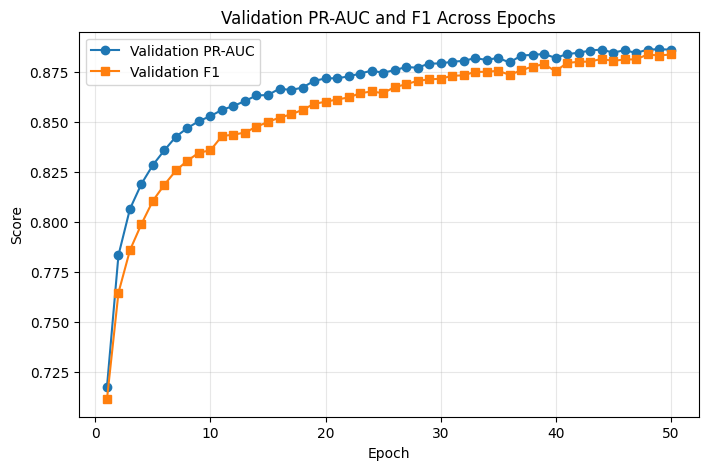

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(hist["epoch"], hist["pr_auc"], marker="o", label="Validation PR-AUC")
plt.plot(hist["epoch"], hist["f1"], marker="s", label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation PR-AUC and F1 Across Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

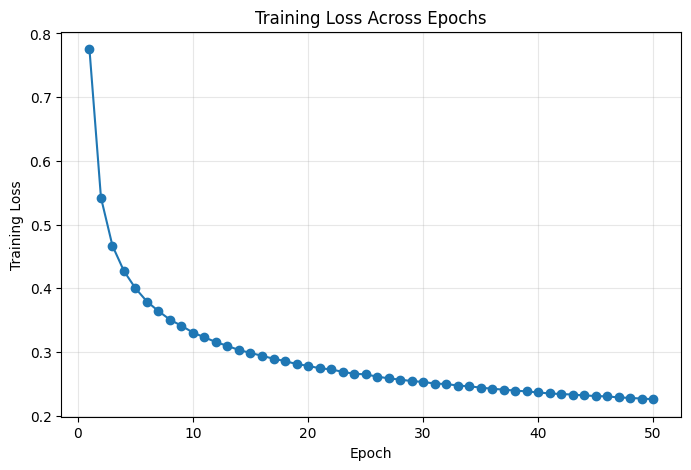

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(hist["epoch"], hist["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Across Epochs")
plt.grid(True, alpha=0.3)
plt.show()